In [1]:
!pip install torch


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import norm
from scipy.special import ndtr
from torch import cat

In [3]:
from src.data_generators import generate_gaussian_mixture, generate_garch11
from src.r_bp import R_BP_density
from src.sampling import R_BP_sample
from src.rho_estimation import estimate_rho_grid
from src.rho_estimation_torch import estimate_rho_adam
from src.lag import lag_k_matrix


[[3 4 0 0 0]
 [1 4 0 0 0]]
[[1 3 4 0 0]]
[[2 3 4 1 0]]


In [4]:
import importlib
import src.data_generators as data
import src.r_bp as rbp
import src.sampling as sampling
import src.rho_estimation as rho_
import src.edit_rho as rho_torch
import src.lag as lag

importlib.reload(data)
importlib.reload(rbp)
importlib.reload(sampling)
importlib.reload(rho_)
importlib.reload(lag)
importlib.reload(rho_torch)

R_BP_sample = sampling.R_BP_sample
lag_k_matrix = lag.lag_k_matrix

### Gaussian mixture data

In [5]:
x = generate_gaussian_mixture(n=300, seed=123)

x_grid = np.linspace(-7, 7, 500)

### intial distribution

In [68]:
kde = gaussian_kde(x)

p0_grid = kde(x_grid)

dx = x_grid[1] - x_grid[0]

P0_grid = np.cumsum(p0_grid) * dx
P0_grid = P0_grid / P0_grid[-1]

def P0_inv(u):
    return np.interp(u, P0_grid, x_grid)

true_density = (0.5 * norm.pdf(x_grid, loc=-2.0, scale=0.5) + 0.5 * norm.pdf(x_grid, loc=2.0, scale=1.0))

### $\rho = 0.65$

In [9]:
rho_fixed = 0.65

p_fixed_mix, P_fixed_mix = R_BP_density(x=x, x_grid=x_grid, rho=rho_fixed, p0_grid=p0_grid, P0_grid=P0_grid)

samples_fixed_mix = R_BP_sample(x=x, x_grid=x_grid, rho=rho_fixed, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

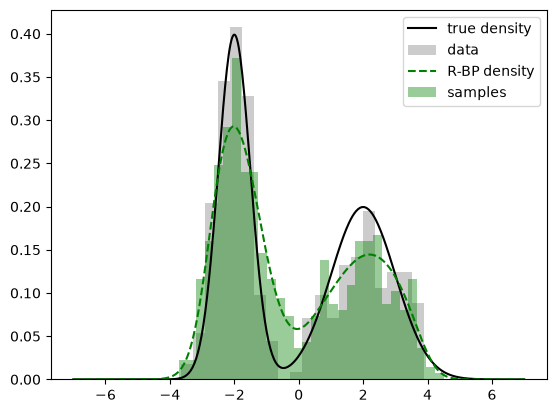

In [69]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_fixed_mix, color="green" ,linestyle="--", label="R-BP density")
plt.hist(samples_fixed_mix, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()

### $\rho$ estiated by grid search

In [ ]:
rho_grid = np.linspace(0.05, 0.95, 50)

best_rho_grid, log_lik_list = estimate_rho_grid(x=x, x_grid=x_grid, p0_grid=p0_grid, P0_grid=P0_grid, rho_grid=rho_grid
)

print("best rho:", best_rho_grid)

In [ ]:
rho_best = best_rho_grid

p_best_rho_grid, P_best_rho_grid = R_BP_density(x=x, x_grid=x_grid,rho=rho_best, p0_grid=p0_grid, P0_grid=P0_grid)

samples_best_rho = R_BP_sample(x=x, x_grid=x_grid, rho=rho_best, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

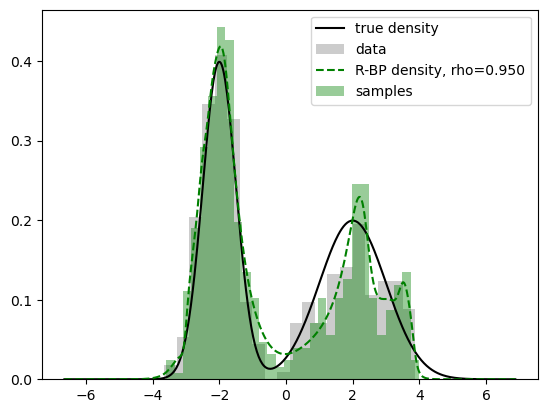

In [34]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_best_rho_grid, color="green", linestyle="--", label=f"R-BP density, rho={rho_best:.3f}")
plt.hist(samples_best_rho, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()

### $\rho$ estiated by ADAM

In [70]:
rho_adam, rho_path_adam, loss_path_adam = estimate_rho_adam(x=x, x_grid=x_grid, p0_grid=p0_grid, P0_grid=P0_grid, lr=0.05, n_iter=300)

print("best rho (ADAM):", rho_adam)

best rho (ADAM): 0.9544341386371324


In [36]:
rho_best_adam = rho_adam

p_best_rho_adam, P_best_rho_adam = R_BP_density(x=x, x_grid=x_grid, rho=rho_best_adam, p0_grid=p0_grid, P0_grid=P0_grid)

samples_best_rho_adam = R_BP_sample(x=x, x_grid=x_grid, rho=rho_best_adam, n=500, P0_grid=P0_grid, P0_inv=P0_inv, seed=1)

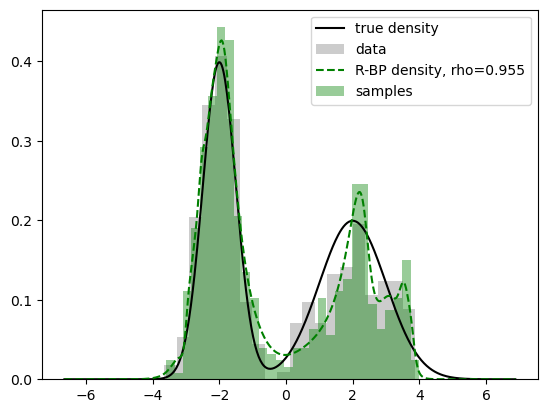

In [37]:
plt.plot(x_grid, true_density, color="black", label="true density")
plt.hist(x, bins=20, density=True, alpha=0.4, color="gray", label="data")
plt.plot(x_grid, p_best_rho_adam, color="green", linestyle="--", label=f"R-BP density, rho={rho_best_adam:.3f}")
plt.hist(samples_best_rho_adam, bins=30, density=True, alpha=0.4, color="green", label="samples")
plt.legend()
plt.show()

Beyond here lies the updated, hopefully faster code for rho evaluation.

(300,)
(800,) (300,)


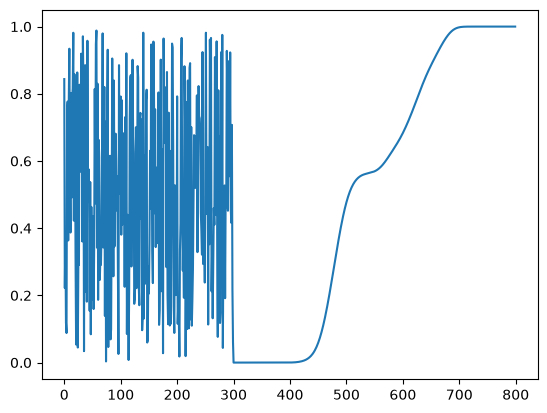

In [6]:
kde = gaussian_kde(x)

x_x_grid = np.concat((x, x_grid), axis=0) 

p0_grid = kde(x)
print(p0_grid.shape)

P0_grid = np.mean(ndtr((x - kde.dataset.T) / kde.factor), axis=0)

other = np.mean(ndtr((x_x_grid - kde.dataset.T) / kde.factor), axis=0)
print(other.shape, P0_grid.shape)
plt.plot(other)



In [61]:
rho_adam, rho_path_adam, loss_path_adam = rho_torch.estimate_rho_adam_edit(n=len(x), p0_grid=p0_grid, P0_grid=P0_grid, lr=0.05, n_iter=300)

print("best rho (ADAM):", rho_adam)

best rho (ADAM): 0.46260362467954697


Test of Minimize from scipy:

This is much faster than torch on a cpu, and likely faster even with gpu speed up. If you use JAX for it's scipy gpu functionality, this may get even faster!

In [93]:
rho = rho_torch.estimate_rho_optim(len(x), p0_grid, P0_grid)

#nll = rho_torch.neg_log_like(0.5, len(x), p0_grid, P0_grid)


Test of the setting of U:

This is to allow the time series transformation, in the univariate case.


In [84]:
import src.r_bp_rho as fix_rho
importlib.reload(fix_rho)

<module 'src.r_bp_rho' from 'c:\\Users\\woodg\\Documents\\Vine_dissertation_chaeyun\\dissertation\\src\\r_bp_rho.py'>

In [94]:
coeffs = fix_rho.R_BP_coefs(rho, p0_grid, P0_grid)

In [1]:
grid = np.linspace(-5, 5, 100)
print(grid.shape)
p0 = kde(grid)
P0 = np.mean(ndtr((grid - kde.dataset.T) / kde.factor), axis=0)

p, P = fix_rho.R_BP_density_U(rho, p0, P0, coeffs)

NameError: name 'np' is not defined

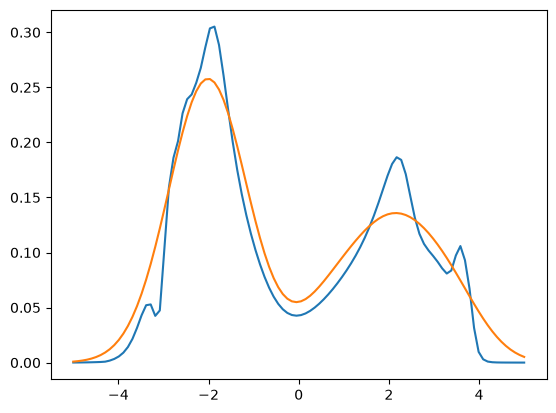

In [97]:
plt.plot(grid, p)
plt.plot(grid, p0)
